# **PHẦN 4: HUẤN LUYỆN MÔ HÌNH**
## **1. Định nghĩa vấn đề**
+ **Mô tả**:
   - Huấn luyện và đánh giá hiệu suất học của mô hình
+ **Mục tiêu**:
   - Huấn luyện và xuất ra file mô hình

## **2. Chuẩn bị vấn đề**

### 2.1. Import các thư viện cần thiết

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow
import math
import itertools

from imblearn.over_sampling import SMOTENC
from imblearn.combine import SMOTETomek

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import learning_curve, RandomizedSearchCV, StratifiedKFold, cross_validate

from sklearn.metrics import classification_report, accuracy_score, f1_score
import time
import joblib

RANDOM_STATE = 42

pd.set_option("display.max_columns", 500)
pd.set_option("display.max_rows", 500)

### 2.2. Lấy tập dữ liệu đã xử lý

In [2]:
x_train = pd.read_parquet("../data_processed/x_train.parquet")
x_train.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Bwd Packet Length Max,Bwd Packet Length Min,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Bwd IAT Total,Bwd IAT Mean,Fwd PSH Flags,Fwd Header Length,Bwd Packets/s,Min Packet Length,FIN Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Init_Win_bytes_backward,Active Mean,Active Std,Idle Mean,Idle Std,s_bit_0,s_bit_1,s_bit_2,s_bit_3,s_bit_4,s_bit_5,s_bit_6,s_bit_7,s_bit_8,s_bit_9,s_bit_10,s_bit_11,s_bit_12,s_bit_13,s_bit_14,s_bit_15,s_bit_16,s_bit_17,s_bit_18,s_bit_19,s_bit_20,s_bit_21,s_bit_22,s_bit_23,s_bit_24,s_bit_25,s_bit_26,s_bit_27,s_bit_28,s_bit_29,s_bit_30,s_bit_31,d_bit_0,d_bit_1,d_bit_2,d_bit_3,d_bit_4,d_bit_5,d_bit_6,d_bit_7,d_bit_8,d_bit_9,d_bit_10,d_bit_11,d_bit_12,d_bit_13,d_bit_14,d_bit_15,d_bit_16,d_bit_17,d_bit_18,d_bit_19,d_bit_20,d_bit_21,d_bit_22,d_bit_23,d_bit_24,d_bit_25,d_bit_26,d_bit_27,d_bit_28,d_bit_29,d_bit_30,d_bit_31,Source Port_Grp_System,Source Port_Grp_Registered,Source Port_Grp_Dynamic,Destination Port_Grp_System,Destination Port_Grp_Registered,Destination Port_Grp_Dynamic,Destination Port_Flag_HTTP,Destination Port_Flag_HTTPS,Destination Port_Flag_DNS,Destination Port_Flag_SSH,Destination Port_Flag_ADB,Destination Port_Flag_VNC,Destination Port_Flag_SMTP,Destination Port_Flag_SMTPS,Destination Port_Flag_FTP,Destination Port_Flag_SQL,Destination Port_Flag_Proxy,Destination Port_Flag_Alt_HTTPS,Destination Port_Flag_Other_System,Destination Port_Flag_Other_Registered,Destination Port_Flag_Dynamic,Hour_sin,Hour_cos,Init_Win_bytes_Bwd_Missing
341993,6.0,-1.756805,0.000000,-0.570892,-0.592211,0.0,-0.601360,0.0,-0.580821,2.341243,-1.924641,0.000000,0.000000,0.000000,0.0,-0.279107,-0.220216,0.0,0.0,0.0,1.0,0.0,-1.0,0.000000,0.000000,0.0,0.000000,0.0,1,1,0,0,1,0,1,0,0,1,0,0,1,1,0,1,1,0,0,0,0,0,0,1,1,0,0,1,0,1,1,0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,5.000000e-01,-0.866025,1
300839,6.0,0.866255,0.261860,0.000000,0.000000,0.0,-0.601360,0.0,-0.527324,-0.573250,1.000553,1.218707,0.000000,0.000000,0.0,0.325849,-0.214466,0.0,0.0,0.0,1.0,1.0,-1.0,0.000000,11.407432,0.0,17.908537,0.0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,1,0,1,0,1,1,0,0,1,1,0,1,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,5.000000e-01,0.866025,0
242949,6.0,0.454056,0.000000,-0.570892,-0.592211,0.0,-0.601360,0.0,-0.580821,-0.517768,0.748422,0.000000,0.000000,0.000000,0.0,0.044619,-0.220216,0.0,0.0,0.0,1.0,1.0,-1.0,0.000000,0.000000,0.0,0.000000,0.0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,0,0,1,0,1,0,1,0,0,0,1,1,1,0,0,0,0,1,0,0,1,1,0,0,0,0,0,1,0,1,0,1,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-8.660254e-01,-0.500000,1
130533,6.0,0.210425,1.182658,0.409325,0.424611,0.0,0.728207,0.0,0.518443,0.082914,-0.193984,0.862406,1.062626,1.049584,0.0,0.904329,0.412438,0.0,0.0,1.0,0.0,0.0,-1.0,0.822864,0.000000,0.0,0.000000,0.0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,1,0,1,1,1,0,1,1,0,1,0,1,1,0,0,1,0,1,0,0,1,1,1,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-5.000000e-01,0.866025,0
287524,6.0,-0.650190,0.000000,-0.570892,-0.592211,0.0,-0.601360,0.0,-0.580821,0.712169,-0.586678,0.000000,0.000000,0.000000,0.0,0.044619,-0.220216,0.0,0.0,0.0,1.0,0.0,-1.0,0.000000,0.000000,0.0,0.000000,0.0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,1,1,0,0,1,1,1,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1.224647e-16,-1.000000,1


In [3]:
x_val = pd.read_parquet("../data_processed/x_val.parquet")
x_val.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Bwd Packet Length Max,Bwd Packet Length Min,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Bwd IAT Total,Bwd IAT Mean,Fwd PSH Flags,Fwd Header Length,Bwd Packets/s,Min Packet Length,FIN Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Init_Win_bytes_backward,Active Mean,Active Std,Idle Mean,Idle Std,s_bit_0,s_bit_1,s_bit_2,s_bit_3,s_bit_4,s_bit_5,s_bit_6,s_bit_7,s_bit_8,s_bit_9,s_bit_10,s_bit_11,s_bit_12,s_bit_13,s_bit_14,s_bit_15,s_bit_16,s_bit_17,s_bit_18,s_bit_19,s_bit_20,s_bit_21,s_bit_22,s_bit_23,s_bit_24,s_bit_25,s_bit_26,s_bit_27,s_bit_28,s_bit_29,s_bit_30,s_bit_31,d_bit_0,d_bit_1,d_bit_2,d_bit_3,d_bit_4,d_bit_5,d_bit_6,d_bit_7,d_bit_8,d_bit_9,d_bit_10,d_bit_11,d_bit_12,d_bit_13,d_bit_14,d_bit_15,d_bit_16,d_bit_17,d_bit_18,d_bit_19,d_bit_20,d_bit_21,d_bit_22,d_bit_23,d_bit_24,d_bit_25,d_bit_26,d_bit_27,d_bit_28,d_bit_29,d_bit_30,d_bit_31,Source Port_Grp_System,Source Port_Grp_Registered,Source Port_Grp_Dynamic,Destination Port_Grp_System,Destination Port_Grp_Registered,Destination Port_Grp_Dynamic,Destination Port_Flag_HTTP,Destination Port_Flag_HTTPS,Destination Port_Flag_DNS,Destination Port_Flag_SSH,Destination Port_Flag_ADB,Destination Port_Flag_VNC,Destination Port_Flag_SMTP,Destination Port_Flag_SMTPS,Destination Port_Flag_FTP,Destination Port_Flag_SQL,Destination Port_Flag_Proxy,Destination Port_Flag_Alt_HTTPS,Destination Port_Flag_Other_System,Destination Port_Flag_Other_Registered,Destination Port_Flag_Dynamic,Hour_sin,Hour_cos,Init_Win_bytes_Bwd_Missing
108563,6.0,0.308921,0.000000,-0.570892,-0.592211,0.0,-0.601360,0.0,-0.580821,-0.450671,0.572945,0.000000,0.000000,0.000000,0.0,-0.279107,-0.220216,0.0,0.0,0.0,1.0,1.0,-1.0,0.000000,0.000000,0.0,0.000000,0.0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,1,1,0,1,1,0,1,1,1,1,1,1,0,1,0,0,0,1,1,1,0,0,1,1,1,1,0,1,0,1,1,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.500000,-0.866025,1
339692,6.0,0.639939,0.261860,-0.570892,-0.592211,0.0,-0.601360,0.0,-0.580821,-0.535380,0.726925,1.131617,0.000000,0.000000,0.0,0.199214,-0.201096,0.0,0.0,1.0,0.0,0.0,-1.0,1.636899,0.000000,0.0,0.000000,0.0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,1,0,0,1,1,1,0,1,0,0,0,1,1,1,1,1,1,1,1,1,0,1,1,0,0,1,1,0,1,0,1,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,-0.866025,0.500000,0
145288,6.0,-0.146969,0.000000,-0.570892,-0.592211,0.0,-0.601360,0.0,-0.580821,0.103439,-0.133614,0.841605,0.000000,0.000000,0.0,0.044619,0.335725,0.0,0.0,0.0,1.0,1.0,-1.0,1.011778,0.000000,0.0,0.000000,0.0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,1,1,0,1,0,1,1,0,0,1,1,0,1,1,0,0,1,0,0,0,0,1,0,1,0,1,1,1,0,1,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.866025,-0.500000,0
74532,6.0,0.866925,0.261860,-0.570892,-0.592211,0.0,0.031000,0.0,-0.527482,-0.569108,0.936883,1.208750,1.435116,1.681092,0.0,0.126160,-0.208849,0.0,0.0,0.0,1.0,0.0,-1.0,1.136141,0.000000,0.0,0.000000,0.0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,0,1,1,0,0,1,1,1,1,1,1,0,1,0,1,1,0,0,1,0,1,1,1,0,1,1,0,1,0,0,1,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,-0.866025,-0.500000,0
87030,6.0,0.755895,1.929947,0.804863,0.652002,0.0,0.728207,0.0,0.188997,-0.343570,0.245678,1.072755,1.386679,1.326063,0.0,1.573624,-0.024373,0.0,0.0,1.0,0.0,0.0,0.0,1.128043,14.956261,0.0,17.216063,0.0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,1,0,1,0,0,0,1,1,1,0,1,1,0,0,0,1,1,0,0,1,0,1,1,1,1,0,1,0,0,1,1,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.866025,0.500000,0


In [4]:
x_test = pd.read_parquet("../data_processed/x_test.parquet")
x_test.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Bwd Packet Length Max,Bwd Packet Length Min,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Bwd IAT Total,Bwd IAT Mean,Fwd PSH Flags,Fwd Header Length,Bwd Packets/s,Min Packet Length,FIN Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Init_Win_bytes_backward,Active Mean,Active Std,Idle Mean,Idle Std,s_bit_0,s_bit_1,s_bit_2,s_bit_3,s_bit_4,s_bit_5,s_bit_6,s_bit_7,s_bit_8,s_bit_9,s_bit_10,s_bit_11,s_bit_12,s_bit_13,s_bit_14,s_bit_15,s_bit_16,s_bit_17,s_bit_18,s_bit_19,s_bit_20,s_bit_21,s_bit_22,s_bit_23,s_bit_24,s_bit_25,s_bit_26,s_bit_27,s_bit_28,s_bit_29,s_bit_30,s_bit_31,d_bit_0,d_bit_1,d_bit_2,d_bit_3,d_bit_4,d_bit_5,d_bit_6,d_bit_7,d_bit_8,d_bit_9,d_bit_10,d_bit_11,d_bit_12,d_bit_13,d_bit_14,d_bit_15,d_bit_16,d_bit_17,d_bit_18,d_bit_19,d_bit_20,d_bit_21,d_bit_22,d_bit_23,d_bit_24,d_bit_25,d_bit_26,d_bit_27,d_bit_28,d_bit_29,d_bit_30,d_bit_31,Source Port_Grp_System,Source Port_Grp_Registered,Source Port_Grp_Dynamic,Destination Port_Grp_System,Destination Port_Grp_Registered,Destination Port_Grp_Dynamic,Destination Port_Flag_HTTP,Destination Port_Flag_HTTPS,Destination Port_Flag_DNS,Destination Port_Flag_SSH,Destination Port_Flag_ADB,Destination Port_Flag_VNC,Destination Port_Flag_SMTP,Destination Port_Flag_SMTPS,Destination Port_Flag_FTP,Destination Port_Flag_SQL,Destination Port_Flag_Proxy,Destination Port_Flag_Alt_HTTPS,Destination Port_Flag_Other_System,Destination Port_Flag_Other_Registered,Destination Port_Flag_Dynamic,Hour_sin,Hour_cos,Init_Win_bytes_Bwd_Missing
228688,17.0,-0.408881,-0.369070,0.023915,0.024808,1.274496,0.267549,4.762174,0.422630,0.363827,-0.294921,0.000000,0.00000,0.000000,0.0,-0.431597,0.769709,3.610918,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,1,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0.500000,8.660254e-01,1
244685,6.0,0.356985,0.000000,-0.570892,-0.592211,0.000000,-0.601360,0.000000,-0.580821,-0.476912,0.631057,0.000000,0.00000,0.000000,0.0,0.044619,-0.220216,0.000000,0.0,0.0,1.0,1.0,-1.0,0.000000,0.0,0.0,0.0,0.0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,1,0,1,0,1,1,0,0,1,1,0,1,1,0,0,1,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,-1.000000,-1.836970e-16,1
158280,6.0,0.196059,0.630930,-0.114178,-0.355326,0.489301,-0.601360,0.000000,-0.281307,-0.031392,-0.079608,0.824203,1.14003,1.184368,1.0,0.354237,0.319545,0.000000,0.0,0.0,1.0,0.0,0.0,1.439836,0.0,0.0,0.0,0.0,0,1,0,0,0,0,1,0,1,1,0,0,0,1,1,0,1,0,1,1,0,0,1,0,0,0,1,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0.866025,5.000000e-01,0
130374,6.0,-0.044289,0.464974,-0.570892,-0.592211,0.000000,0.126472,3.988984,0.035466,0.092650,-0.164827,0.833207,0.00000,0.000000,0.0,0.296265,0.191507,0.000000,0.0,0.0,1.0,1.0,-1.0,0.911983,0.0,0.0,0.0,0.0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,1,1,0,1,1,0,1,0,0,1,0,0,1,0,1,0,1,1,0,0,0,1,0,0,0,1,1,0,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,-0.500000,8.660254e-01,0
110173,6.0,-0.356900,-0.369070,-0.570892,-0.592211,0.000000,-0.601360,0.000000,-0.580821,0.290125,-0.232072,0.000000,0.00000,0.000000,0.0,-0.431597,0.678583,0.000000,0.0,0.0,1.0,1.0,0.0,0.824235,0.0,0.0,0.0,0.0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,1,1,1,0,0,0,1,0,0,1,1,0,1,0,1,1,1,1,0,0,0,1,1,1,1,1,0,1,1,0,0,0,0,1,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.866025,-5.000000e-01,0


In [5]:
y_train = pd.read_parquet("../data_processed/y_train.parquet")
y_train.head()

,Label
341993,3
300839,2
242949,1
130533,0
287524,2


In [6]:
y_val = pd.read_parquet("../data_processed/y_val.parquet")
y_val.head()

,Label
108563,0
339692,3
145288,0
74532,0
87030,0


In [7]:
y_test = pd.read_parquet("../data_processed/y_test.parquet")
y_test.head()

,Label
228688,1
244685,1
158280,1
130374,0
110173,0


## **3. Thực hiện vấn đề**

In [19]:
y_train = y_train.values.ravel()
y_val = y_val.values.ravel()

AttributeError: 'numpy.ndarray' object has no attribute 'values'

In [33]:
strategy = {
    2: 80000, 
    3: 50000
}

cat_indices = [i for i, col in enumerate(x_train.columns) if x_train[col].nunique() <= 3]
spn = SMOTENC(categorical_features=cat_indices, sampling_strategy=strategy, random_state=RANDOM_STATE)

x_train_res, y_train_res = spn.fit_resample(x_train, y_train)

In [34]:

models = {
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, 
                                              class_weight='balanced',
                                              random_state=RANDOM_STATE,
                                              n_jobs=-1),
    "Linear SVM": LinearSVC(dual=False, class_weight='balanced', random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(class_weight='balanced', 
                                            n_jobs=-1, 
                                            max_depth=20,
                                            random_state=RANDOM_STATE),
    "Extra Trees": ExtraTreesClassifier(class_weight='balanced', 
                                        n_jobs=-1, 
                                        max_depth=20,
                                        random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(eval_metric=["mlogloss", "merror"],
                             n_estimators=100,
                             max_depth=20,
                             random_state=RANDOM_STATE),
    "LightGBM": LGBMClassifier(class_weight='balanced', 
                               n_estimators=500,
                               max_depth=20,
                               learning_rate=0.1,
                               n_jobs=-1, 
                               random_state=RANDOM_STATE),
    "CatBoost": CatBoostClassifier(auto_class_weights='Balanced', 
                                   verbose=False, 
                                   iterations=500,
                                   learning_rate=0.1,
                                   depth=6,
                                   random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=15, 
        class_weight='balanced', 
        random_state=RANDOM_STATE
    ),
    "Kernel SVM": SVC(kernel='rbf', C=20.0, class_weight='balanced', max_iter=500, random_state=RANDOM_STATE),
}

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_res)

In [9]:
model_performance = []
training_logs = {}

for name, model in models.items():
    print(f"Training {name}...")
    start_time = time.time()
    
    if name in ["XGBoost", "LightGBM", "CatBoost"]:
        if name == "XGBoost":
            model.fit(x_train, y_train, sample_weight=sample_weights,
                      eval_set=[(x_train, y_train), (x_val, y_val)],
                      verbose=False)
            training_logs[name] = model.evals_result()
            
        elif name == "LightGBM":
            import lightgbm as lgb
            
            model.fit(x_train, y_train,
                      eval_set=[(x_train, y_train), (x_val, y_val)],
                      eval_metric=['multi_logloss', 'multi_error'],
                      callbacks=[lgb.log_evaluation(period=0)])
            training_logs[name] = model.evals_result_
            
        elif name == "CatBoost":
            model.fit(x_train, y_train,
                      eval_set=(x_val, y_val),
                      verbose=False,
                      early_stopping_rounds=10)
            training_logs[name] = model.get_evals_result()
    else:
        model.fit(x_train, y_train)
    
    training_time = time.time() - start_time

    y_pred = model.predict(x_val)
    f1 = f1_score(y_val, y_pred, average='macro')
    acc = accuracy_score(y_val, y_pred)
    
    model_performance.append({
        "Model": name,
        "Accuracy": acc,
        "Macro F1-Score": f1,
        "Time (s)": training_time
    })
    
    print(f"Completed {name} in {training_time:.2f}s | F1: {f1:.4f} | Acc: {acc:.4f}\n")


Training K-Nearest Neighbors...
Completed K-Nearest Neighbors in 0.19s | F1: 0.6158 | Acc: 0.6830

Training Naive Bayes...
Completed Naive Bayes in 0.55s | F1: 0.3179 | Acc: 0.4460

Training Logistic Regression...
Completed Logistic Regression in 101.67s | F1: 0.4151 | Acc: 0.4433

Training Linear SVM...
Completed Linear SVM in 100.59s | F1: 0.4318 | Acc: 0.4983

Training Random Forest...
Completed Random Forest in 10.92s | F1: 0.6904 | Acc: 0.7361

Training Extra Trees...
Completed Extra Trees in 13.38s | F1: 0.6938 | Acc: 0.7337

Training XGBoost...
Completed XGBoost in 64.53s | F1: 0.7370 | Acc: 0.7731

Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028496 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5210
[LightGBM] [Info] Number 

d:\Installs\Anaconda\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Completed Kernel SVM in 67.07s | F1: 0.1944 | Acc: 0.3890



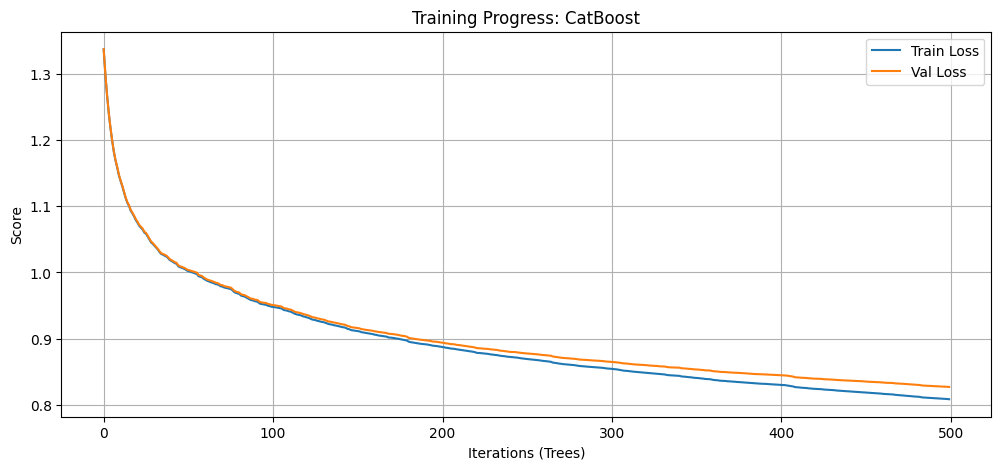

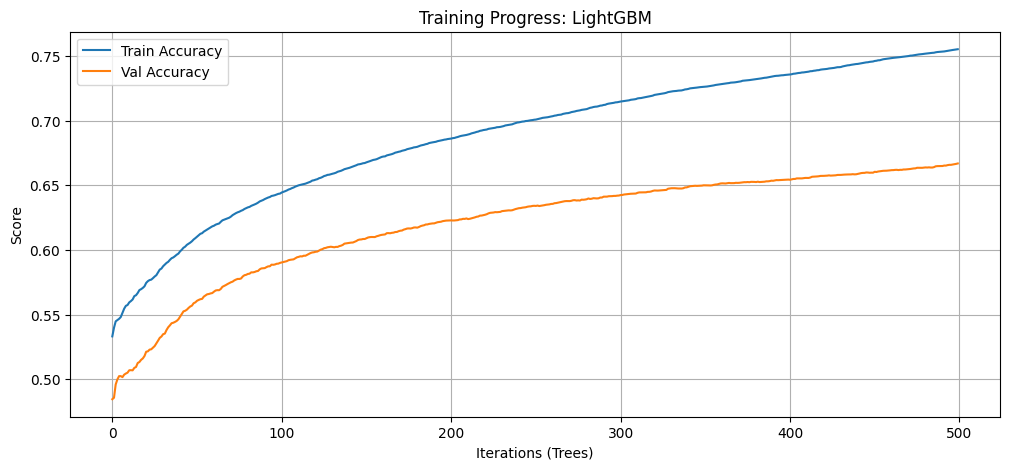

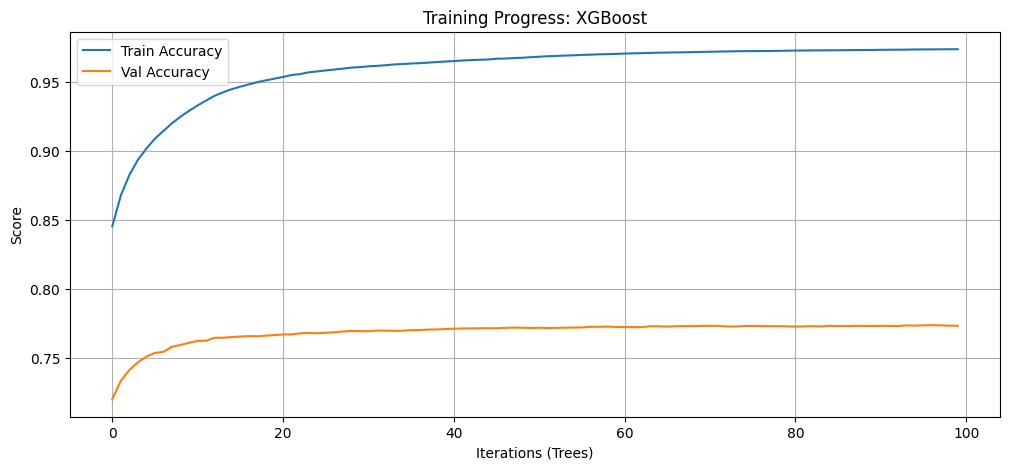

In [10]:
def plot_booster_logs(logs, model_name):
    plt.figure(figsize=(12, 5))
    
    if model_name == "XGBoost":
        if 'merror' in logs[model_name]['validation_0']:
            train_acc = [1 - x for x in logs[model_name]['validation_0']['merror']]
            val_acc = [1 - x for x in logs[model_name]['validation_1']['merror']]
            plt.plot(train_acc, label='Train Accuracy')
            plt.plot(val_acc, label='Val Accuracy')
        else:
            plt.plot(logs[model_name]['validation_0']['mlogloss'], label='Train Logloss')
            plt.plot(logs[model_name]['validation_1']['mlogloss'], label='Val Logloss')
            plt.ylabel('Logloss')

    elif model_name == "LightGBM":
        train_acc = [1 - x for x in logs[model_name]['training']['multi_error']]
        val_acc = [1 - x for x in logs[model_name]['valid_1']['multi_error']]
        plt.plot(train_acc, label='Train Accuracy')
        plt.plot(val_acc, label='Val Accuracy')
        
    elif model_name == "CatBoost":
        if 'Accuracy' in logs[model_name]['validation']:
            plt.plot(logs[model_name]['learn']['Accuracy'], label='Train Accuracy')
            plt.plot(logs[model_name]['validation']['Accuracy'], label='Val Accuracy')
        else:
            plt.plot(logs[model_name]['learn']['MultiClass'], label='Train Loss')
            plt.plot(logs[model_name]['validation']['MultiClass'], label='Val Loss')
            plt.ylabel('Loss')

    plt.title(f"Training Progress: {model_name}")
    plt.xlabel("Iterations (Trees)")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)
    plt.show()


if "CatBoost" in training_logs:
    plot_booster_logs(training_logs, "CatBoost")

if "LightGBM" in training_logs:
    plot_booster_logs(training_logs, "LightGBM")

if "XGBoost" in training_logs:
    plot_booster_logs(training_logs, "XGBoost")

Generating learning curve for Random Forest...


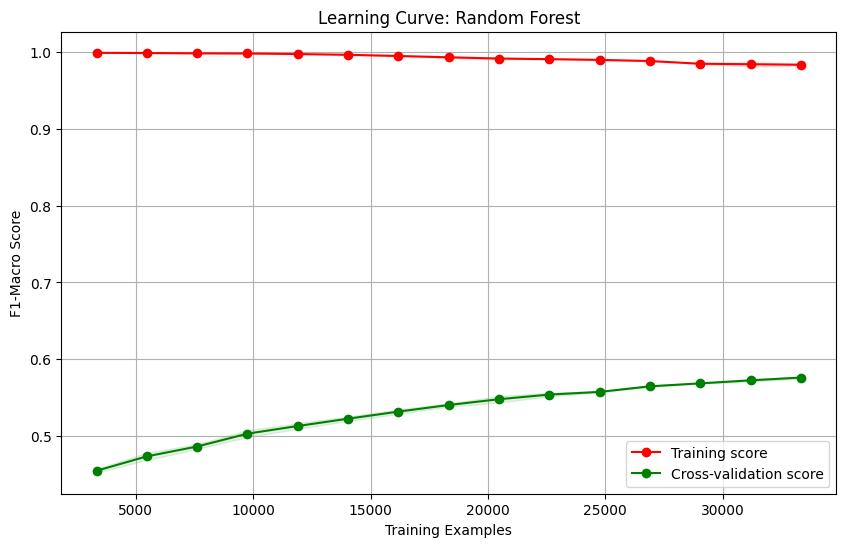

Generating learning curve for LogisticRegression...


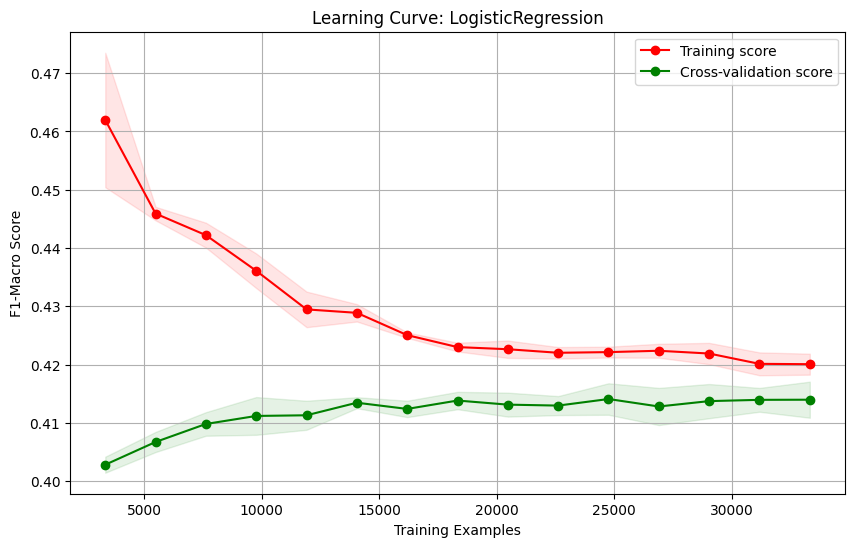

Generating learning curve for ExtraTreesClassifier...


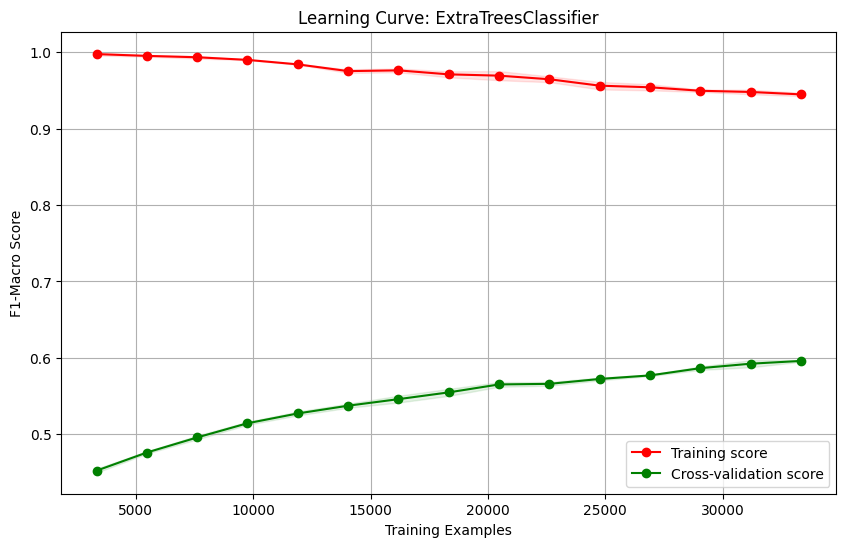

Generating learning curve for LinearSVC...


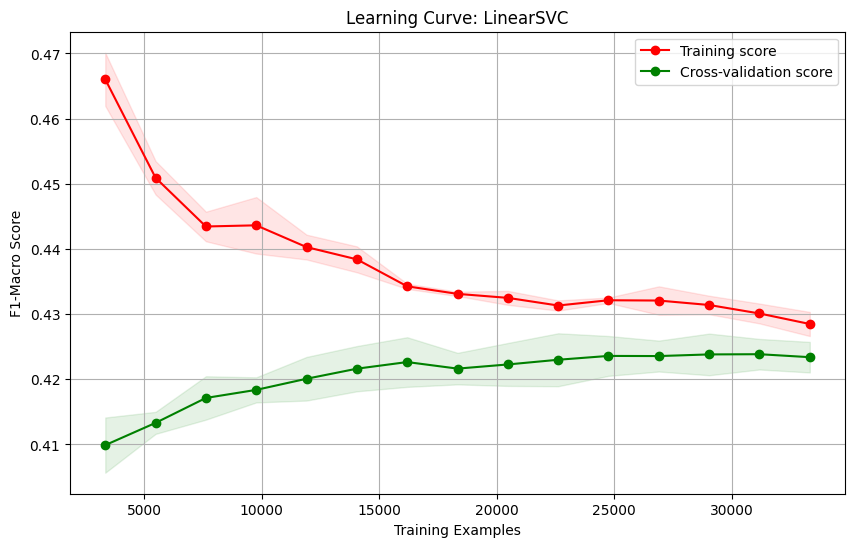

Generating learning curve for KNearestNeighbors...


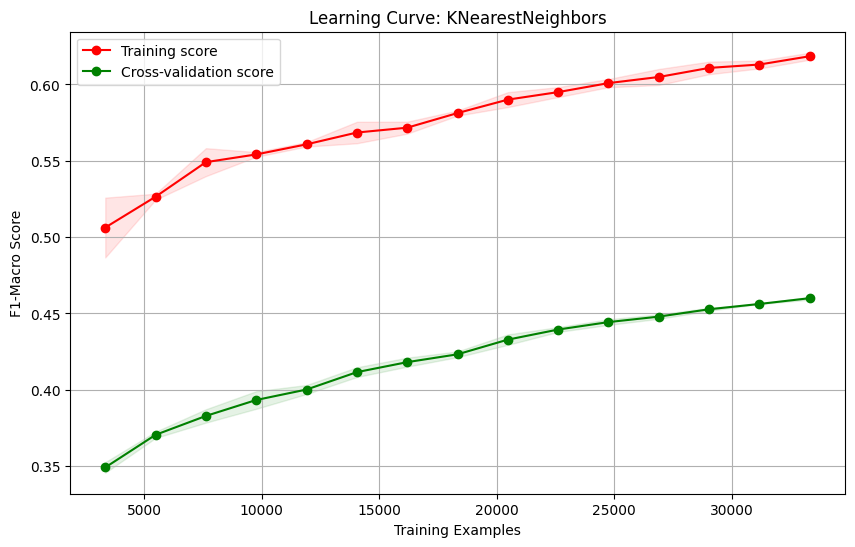

Generating learning curve for KernelSVM...


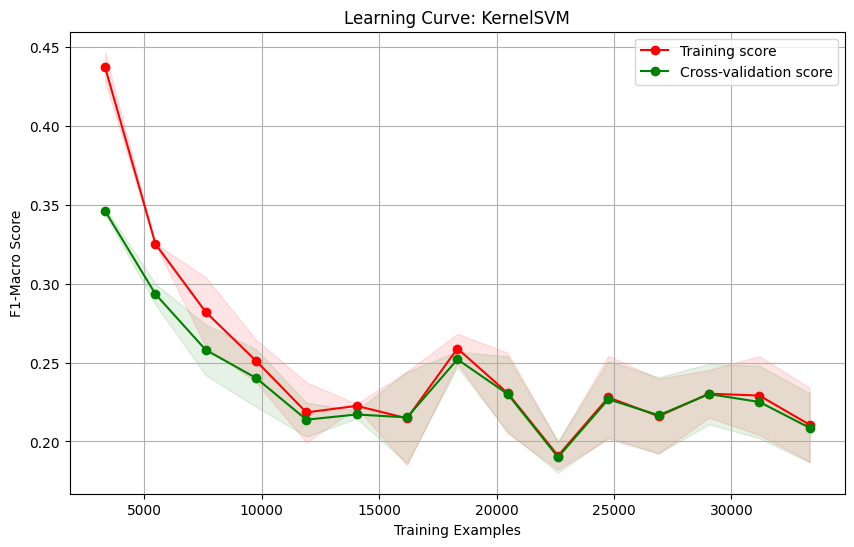

Generating learning curve for DecisionTree...


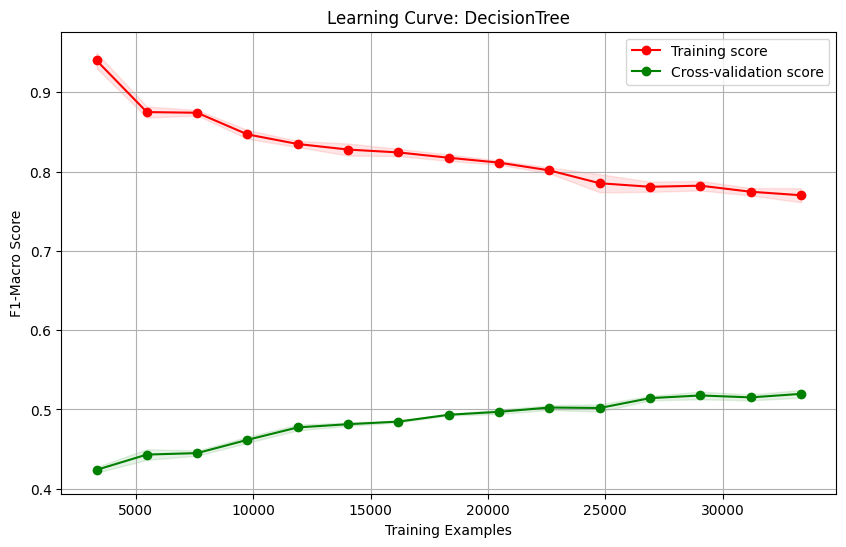

Generating learning curve for NaiveBayes...


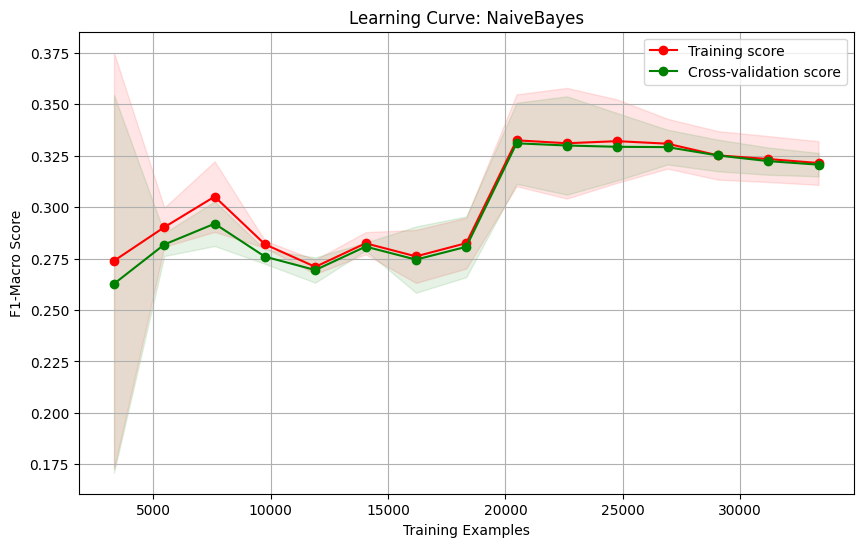

In [11]:
def plot_learning_curve(model, name, X : pd.DataFrame, y : pd.DataFrame):
    print(f"Generating learning curve for {name}...")
    
    sample_idx = np.random.choice(len(X), 50000, replace=False)
    x_diag = X.iloc[sample_idx]
    y_diag = y.ravel()[sample_idx]

    train_sizes, train_scores, test_scores = learning_curve(
        model, x_diag, y_diag, 
        train_sizes=np.linspace(0.1, 1.0, 15),
        cv=3, 
        scoring='f1_macro', 
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

    plt.title(f"Learning Curve: {name}")
    plt.xlabel("Training Examples")
    plt.ylabel("F1-Macro Score")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

plot_learning_curve(models["Random Forest"], "Random Forest", x_train, y_train)
plot_learning_curve(models["Logistic Regression"], "LogisticRegression", x_train, y_train)
plot_learning_curve(models["Extra Trees"], "ExtraTreesClassifier", x_train, y_train)
plot_learning_curve(models["Linear SVM"], "LinearSVC", x_train, y_train)
plot_learning_curve(models["K-Nearest Neighbors"], "KNearestNeighbors", x_train, y_train)
plot_learning_curve(models["Kernel SVM"], "KernelSVM", x_train, y_train)
plot_learning_curve(models["Decision Tree"], "DecisionTree", x_train, y_train)
plot_learning_curve(models["Naive Bayes"], "NaiveBayes", x_train, y_train)

In [12]:
# tuning_configs = {
#     "XGBoost": {
#         "model": models["XGBoost"],
#         "params": {
#             'n_estimators': [50, 100, 200, 400],
#             'max_depth': [5, 10, 20],
#             'learning_rate': [0.01, 0.05, 0.1],
#             'subsample': [0.8, 1.0]
#         }
#     },
#     "LightGBM": {
#         "model": models["LightGBM"],
#         "params": {
#             'n_estimators': [500, 1000, 1500, 2000],
#             'num_leaves': [32, 64, 128],
#             'learning_rate': [0.1, 0.5],
#             'boosting_type': ['gbdt', 'dart']
#         }
#     },
#     "Random Forest": {
#         "model": models["Random Forest"],
#         "params": {
#             'n_estimators': [100, 200, 300],
#             'max_depth': [15, 20, 30],
#             'min_samples_leaf': [10, 50, 100],
#             'max_features': ['sqrt', 'log2']
#         }
#     },
#     "Decision Tree": {
#         "model": models["Decision Tree"],
#         "params": {
#             'max_depth': [15, 20, 30],
#             'min_samples_split': [2, 10, 50],
#             'min_samples_leaf': [1, 5, 20],
#             'criterion': ['gini', 'entropy']
#         }
#     },
#     "Extra Trees": {
#         "model": models["Extra Trees"],
#         "params": {
#             'n_estimators': [100, 200, 300],
#             'max_depth': [10, 20, 30],
#             'min_samples_leaf': [10, 50, 100],
#             'max_features': ['sqrt', 'log2', None]
#         }
#     },
#     "K-Nearest Neighbors": {
#         "model": models["K-Nearest Neighbors"],
#         "params": {
#             'n_neighbors': [5, 11, 21, 31, 41, 51],
#             'weights': ['uniform', 'distance'],
#             'metric': ['euclidean', 'manhattan']
#         }
#     }
# }

# best_models = {}

# for name, config in tuning_configs.items():
#     print(f"Tuning {name}...")
    
#     rs = RandomizedSearchCV(
#         estimator=config["model"],
#         param_distributions=config["params"],
#         n_iter=50, 
#         cv=5,
#         scoring='f1_macro',
#         n_jobs=5,
#         random_state=RANDOM_STATE,
#         verbose=1
#     )

#     rs.fit(x_train, y_train)
    
#     print(f"Best Params for {name}: {rs.best_params_}")
#     best_models[name] = rs.best_estimator_
    
#     models[name] = rs.best_estimator_

In [39]:
tuned_models = {
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5, weights="distance", metric="manhattan", n_jobs=-1),
    "Random Forest": RandomForestClassifier(class_weight='balanced', 
                                            n_jobs=-1, 
                                            n_estimators=100,
                                            random_state=RANDOM_STATE),
    "Extra Trees": ExtraTreesClassifier(class_weight='balanced', 
                                        n_jobs=-1, 
                                        n_estimators=100,
                                        random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=200,
                             max_depth=20,
                             learning_rate=0.05,
                             subsample=1.0,
                             max_delta_step=5,
                             reg_lambda=10,
                             random_state=RANDOM_STATE),
    "LightGBM": LGBMClassifier(class_weight='balanced', 
                               n_estimators=2500,
                               num_leaves=128,
                               learning_rate=0.1,
                               n_jobs=-1, 
                               random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(
        class_weight='balanced', 
        random_state=RANDOM_STATE
    ),
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 1

In [ ]:
for name, model in tuned_models.items():
    print(f"Training {name}...")
    start_time = time.time()
    
    if name in ["XGBoost"]:
        model.fit(x_train_res, y_train_res, sample_weight=sample_weights)

    else:
        model.fit(x_train_res, y_train_res)
    
    training_time = time.time() - start_time

    y_probs = model.predict_proba(x_val)
    threshold = 0.7
    y_pred_custom = []

    for prob in y_probs:
        if prob[3] > threshold:
            y_pred_custom.append(3)
        else:
            y_pred_custom.append(np.argmax(prob))

    f1 = f1_score(y_val, y_pred_custom, average='macro')
    acc = accuracy_score(y_val, y_pred_custom)
    
    print(f"Completed {name} in {training_time:.2f}s | F1: {f1:.4f} | Acc: {acc:.4f}\n")
    print(classification_report(y_val, y_pred_custom))

Training K-Nearest Neighbors...
Completed K-Nearest Neighbors in 0.23s | F1: 0.6550 | Acc: 0.7033

              precision    recall  f1-score   support

           0       0.78      0.77      0.78     14744
           1       0.69      0.66      0.67     11708
           2       0.65      0.70      0.68      6740
           3       0.46      0.53      0.49      2371

    accuracy                           0.70     35563
   macro avg       0.65      0.66      0.65     35563
weighted avg       0.71      0.70      0.70     35563

Training Random Forest...
Completed Random Forest in 16.16s | F1: 0.7059 | Acc: 0.7526

              precision    recall  f1-score   support

           0       0.80      0.83      0.82     14744
           1       0.73      0.72      0.72     11708
           2       0.73      0.71      0.72      6740
           3       0.61      0.53      0.56      2371

    accuracy                           0.75     35563
   macro avg       0.72      0.70      0.71     3556

## 2

              precision    recall  f1-score   support

           0       0.78      0.75      0.76     14744
           1       0.68      0.64      0.66     11708
           2       0.62      0.69      0.65      6740
           3       0.43      0.52      0.47      2371

    accuracy                           0.69     35563
   macro avg       0.63      0.65      0.64     35563
weighted avg       0.69      0.69      0.69     35563

